In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
Batch_Size = 32
LR = 1e-5
Num_Epochs = 2
Sigma_Begin = 1.00
Sigma_End = 0.01
Num_classes = 10

cuda


### Data Loading(CIFAR - 10)

In [ ]:
from IPython.testing import test
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = Batch_Size, shuffle=False)

 14%|█▎        | 23.1M/170M [06:16<34:06, 72.0kB/s]

Each image has its own noise level.

# Why Do We Use Fourier Features in Noise Conditional Score Networks?

In a Noise Conditional Score Network (NCSN), the model does not only receive a noisy image (x). It also needs to know **how much noise was added** to that image.

Therefore, the model learns a function of the form:

[
s_\theta(x,\sigma)
]

where:

* (x) = noisy image
* (\sigma) = noise level
* (s_\theta(x,\sigma)) = predicted score

The important question is:

> **How should we provide the scalar noise level (\sigma) to the neural network?**

A simple approach would be to give the network the scalar (\sigma) directly. However, a single scalar is a very low-dimensional representation, and the desired behavior of the score network can change in a complicated, nonlinear way as (\sigma) changes.

To make it easier for the neural network to learn this relationship, we convert (\sigma) into a high-dimensional representation using **Fourier features**.

---

## 1. What is the Fourier idea?

The basic idea behind Fourier analysis is that complicated signals can be represented using combinations of simple sinusoidal waves:

[
f(t)
\approx
A_1\sin(2\pi f_1t)
+
A_2\sin(2\pi f_2t)
+\cdots
]

Different frequencies capture different patterns or scales of variation.

For example:

```text
Low frequency:

      ~~~~~~~~~~~~~~~


Medium frequency:

     ~~~   ~~~   ~~~


High frequency:

   ~ ~ ~ ~ ~ ~ ~ ~ ~
```

This idea can also be used to represent a scalar value using sinusoidal functions with different frequencies.

---

## 2. Important: We Are NOT Fourier Transforming the Image

Although this technique is called a Fourier feature embedding, we are **not applying a Fourier transform to the image**.

We are not doing:

[
\text{Image}
\rightarrow
\text{Frequency domain}
]

Instead, we are taking the scalar noise level:

[
\sigma
]

and mapping it to a vector:

[
\sigma
\rightarrow
[
\sin(2\pi w_1\sigma),
\cos(2\pi w_1\sigma),
\ldots
]
]

So the Fourier operation is being used to create a **rich representation of the noise level**, not to process the image itself.

---

# 3. Why Do We Need a Rich Representation of (\sigma)?

Suppose we only give the network:

[
\sigma=0.1
]

The network has to learn how its behavior should change for every possible noise level:

[
0.01,;0.02,;0.05,;0.1,;0.5,;1,;5,;10,\ldots
]

The relationship between noise level and the desired score can be highly nonlinear.

Fourier features transform the scalar into many sinusoidal features at different frequencies:

[
\sigma
\rightarrow
\begin{bmatrix}
\sin(2\pi w_1\sigma)\
\cos(2\pi w_1\sigma)\
\sin(2\pi w_2\sigma)\
\cos(2\pi w_2\sigma)\
\vdots\
\sin(2\pi w_k\sigma)\
\cos(2\pi w_k\sigma)
\end{bmatrix}
]

This gives the neural network a much more expressive representation from which it can learn complicated functions of (\sigma).

---

# 4. Why Multiple Frequencies?

Instead of using just one sinusoidal function:

[
\sin(\sigma)
]

we use many different frequencies:

[
\sin(w_1\sigma),
\sin(w_2\sigma),
\sin(w_3\sigma),
\ldots
]

Some frequencies vary slowly:

```text
Low frequency
   ~~~~~~~~~~~~~~~~
```

while others vary rapidly:

```text
High frequency
   ~ ~ ~ ~ ~ ~ ~ ~
```

Therefore, the embedding provides information about the noise level at multiple scales.

The neural network can then learn how to combine these features.

---

# 5. Why Do We Use Both Sine and Cosine?

We use:

[
\sin(2\pi w\sigma)
]

and

[
\cos(2\pi w\sigma)
]

together.

For a particular frequency (w), they form a pair:

[
[
\sin(2\pi w\sigma),
\cos(2\pi w\sigma)
]
]

This gives a more complete representation of the phase of the sinusoidal signal.

Therefore, for multiple frequencies, we obtain a vector such as:

[
[
\sin(2\pi w_1\sigma),
\ldots,
\sin(2\pi w_k\sigma),
\cos(2\pi w_1\sigma),
\ldots,
\cos(2\pi w_k\sigma)
]
]

---

# 6. What Happens in Our Implementation?

In our implementation:

```python
class GaussianFourierProjection(nn.Module):
    """Embeds scalar noise levels labels into vectors."""

    def __init__(self, embed_dim, scale=30.0):
        super().__init__()

        self.W = nn.Parameter(
            torch.randn(embed_dim // 2) * scale,
            requires_grad=False
        )

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi

        return torch.cat(
            [torch.sin(x_proj), torch.cos(x_proj)],
            dim=-1
        )
```

Suppose:

```python
embed_dim = 256
```

Then:

[
\frac{256}{2}=128
]

random frequencies are generated:

[
W=[w_1,w_2,\ldots,w_{128}]
]

For every noise level (\sigma), we calculate:

[
2\pi\sigma W
]

which gives:

[
[
2\pi w_1\sigma,
2\pi w_2\sigma,
\ldots,
2\pi w_{128}\sigma
]
]

Then we apply sine and cosine.

Therefore:

[
128\text{ sine features}
+
128\text{ cosine features}
==========================

256\text{ features}
]

So:

[
\boxed{
\sigma
\rightarrow
\text{256-dimensional Fourier embedding}
}
]

---

# 7. What Happens for a Batch?

Suppose we have a batch of 32 images:

[
x.shape=(32,3,32,32)
]

and 32 corresponding noise levels:

[
\sigma.shape=(32,)
]

For example:

```text
Image 0 → σ = 0.01
Image 1 → σ = 0.05
Image 2 → σ = 0.10
...
Image 31 → σ = 10.0
```

The Fourier projection operates on all 32 noise levels simultaneously:

```text
σ
(32,)
 │
 ▼
Gaussian Fourier Projection
 │
 ▼
(32, 256)
```

Therefore:

```text
Image 0 → σ₀ → 256-dimensional embedding
Image 1 → σ₁ → 256-dimensional embedding
Image 2 → σ₂ → 256-dimensional embedding
...
Image 31 → σ₃₁ → 256-dimensional embedding
```

The batch dimension is preserved throughout this process.

---

# 8. How Does the Embedding Enter the U-Net?

The image travels through the U-Net:

```text
Image
  │
  ▼
Conv layer
  │
  ▼
Feature maps
  │
  ▼
Downsampling
  │
  ▼
Deeper features
  │
  ▼
Upsampling
  │
  ▼
Score
```

At the same time, (\sigma) travels through:

```text
σ
 │
 ▼
Fourier Projection
 │
 ▼
256-dimensional embedding
 │
 ▼
Dense layer
 │
 ▼
Channel-wise conditioning
```

The resulting noise embedding is added to the feature maps at multiple stages of the U-Net.

Conceptually:

```text
                    σ
                    │
                    ▼
           Fourier Embedding
                    │
                    ▼
              Noise Embedding
                    │
        ┌───────────┼───────────┐
        ▼           ▼           ▼
      Dense       Dense       Dense
        │           │           │
        ▼           ▼           ▼
       U-Net       U-Net       U-Net
        │           │           │
        └───────────┼───────────┘
                    │
                    ▼
              Predicted Score
```

Thus, the U-Net knows **which noise level it is currently processing**.

---

# 9. Why Is This Important for Score Matching?

In NCSN, the target score depends on the noise level:

[
s_\theta(x,\sigma)
\approx
\nabla_x \log p_\sigma(x)
]

Different values of (\sigma) produce different noisy data distributions:

[
p_{\sigma_1}(x)
\neq
p_{\sigma_2}(x)
]

Therefore, the score is also different:

[
\nabla_x\log p_{\sigma_1}(x)
\neq
\nabla_x\log p_{\sigma_2}(x)
]

The same noisy-looking image may therefore require different score predictions depending on the noise level used to generate it.

The Fourier embedding provides the network with this crucial conditioning information.

---

# 10. Connection to Diffusion Models

This idea is closely related to **time embeddings in diffusion models**.

In a DDPM, we often have:

[
t
\rightarrow
\text{time embedding}
\rightarrow
\text{U-Net}
]

where (t) is the diffusion timestep.

In an NCSN:

[
\sigma
\rightarrow
\text{Fourier embedding}
\rightarrow
\text{U-Net}
]

where (\sigma) is the noise level.

So you can think of Fourier embedding as a way of saying:

> **"Here is a rich representation of the current noise level so that the U-Net can adjust its prediction according to how noisy the input is."**

---

# Summary

The complete idea is:

[
\boxed{
\sigma
\rightarrow
\text{Fourier Features}
\rightarrow
\text{High-dimensional embedding}
\rightarrow
\text{U-Net conditioning}
\rightarrow
s_\theta(x,\sigma)
}
]

The Fourier embedding is **not transforming the image into the frequency domain**.

Instead, it transforms the **scalar noise level (\sigma)** into a rich vector using sine and cosine functions at multiple frequencies.

This helps the neural network learn the potentially complicated relationship:

[
\boxed{
\sigma
\rightarrow
\text{how the score network should behave}
}
]

For a batch of 32 images, the process is simply:

[
(32,)
\xrightarrow{\text{Fourier}}
(32,256)
]

while the images follow:

[
(32,3,H,W)
\xrightarrow{\text{U-Net}}
(32,3,H,W)
]

and the Fourier embeddings are injected into the U-Net at different stages to make the score prediction **conditional on the noise level**.


Hey basically like we attach the time embedding in images like for each channel of image we attach same time to all pixels similarly here we are adding sigma value
Basically the sigma values replaces the time embedding

In [ ]:
class GaussianFourierProjection(nn.Module):
    ### Embeds scalar noise levels labels into vectors."""
    ### hey these is not applied over images else this is applied over sigma value to convert them into tensors
    def __init__(self, embed_dim, scale=30.0):
        super().__init__()
        # Randomly initialized frequencies, not trainable (standard practice in Score models)
        self.W = nn.Parameter(
            torch.randn(embed_dim // 2) * scale, requires_grad=False
        )    #### creates a vector of shape  (embed_dim//2, )

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi    ### (B, 1) * (1, embed_dim//2) --> (B, embed_dim//2)  **** here B refers to num of sigma values
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)    ### (B, embed_dim)


class ScoreNet(nn.Module):
    def __init__(self, channels=[32, 64, 128, 256], embed_dim=256):
        super().__init__()

        # Gaussian Fourier Projection for noise levels
        self.embed = GaussianFourierProjection(embed_dim)

        # U-Net Encoder
        self.conv1 = nn.Conv2d(3, channels[0], 3, stride=1, padding=1)
        self.dense1 = nn.Linear(embed_dim, channels[0])[..., None, None]
        self.gn1 = nn.GroupNorm(4, channels[0])

        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, padding=1)
        self.dense2 = nn.Linear(embed_dim, channels[1])[..., None, None]
        self.gn2 = nn.GroupNorm(32, channels[1])

        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, padding=1)
        self.dense3 = nn.Linear(embed_dim, channels[2])[..., None, None]
        self.gn3 = nn.GroupNorm(32, channels[2])
        self.tconv2 = nn.ConvTranspose2d(channels[2], channels[1], 3, stride=2, padding=1, output_padding=1)
        self.dense4 = nn.Linear(embed_dim, channels[1])[..., None, None]
        self.gn4 = nn.GroupNorm(32, channels[1])

        self.tconv1 = nn.ConvTranspose2d(channels[1] * 2, channels[0], 3, stride=2, padding=1, output_padding=1) # *2 for skip con
        self.dense5 = nn.Linear(embed_dim, channels[0])[..., None, None]
        self.gn5 = nn.GroupNorm(32, channels[0])

        self.final = nn.Conv2d(channels[0] * 2, 3, 3, stride=1, padding=1)

        self.act = nn.SiLU() # Swish activation

    def forward(self, x, sigma_labels):
        # # Embed the noise level
        embed = self.act(self.embed(sigma_labels))

        # # Encoding
        h1 = self.conv1(x)

        # # Add conditioning: Feature map + Embedding
        h1 += self.dense1(embed)
        h1 = self.act(self.gn1(h1))

        h2 = self.conv2(h1)
        h2 += self.dense2(embed)
        h2 = self.act(self.gn2(h2))

        h3 = self.conv3(h2)
        h3 += self.dense3(embed)
        h3 = self.act(self.gn3(h3))

        # Decoding with Skip Connections
        h2_dec = self.tconv2(h3)
        h2_dec += self.dense4(embed)
        h2_dec = self.act(self.gn4(h2_dec))

        # Skip connection from encoder h2
        h2_cat = torch.cat([h2_dec, h2], dim=1)

        h1_dec = self.tconv1(h2_cat)
        h1_dec += self.dense5(embed)
        h1_dec = self.act(self.gn5(h1_dec))

        # Skip connection from encoder h1
        h1_cat = torch.cat([h1_dec, h1], dim=1)

        out = self.final(h1_cat)

        # Normalize output by sigma (Paper trick: estimate s(x) * sigma instead of s(x)
        # We return the raw output; the loss handles the scaling.
        return out / sigma_labels[:, None, None, None]


# Visualizing How a Batch of 32 Images Passes Through NCSN ScoreNet

Assume we have a batch of 32 RGB images of size (32\times32):

[
x.shape=(32,3,32,32)
]

where:

* `32` = batch size
* `3` = RGB channels
* `32 × 32` = image height and width

Each image also has a corresponding noise level (\sigma):

[
\sigma.shape=(32,)
]

For example:

```text
Image 0 → σ = 0.01
Image 1 → σ = 0.05
Image 2 → σ = 0.10
...
Image 31 → σ = 10.0
```

---

## 1. Input Batch

```text
Batch
│
├── Image 0  → noisy image, σ = 0.01
├── Image 1  → noisy image, σ = 0.05
├── Image 2  → noisy image, σ = 0.10
├── ...
└── Image 31 → noisy image, σ = 10.0
```

Tensor:

```text
x
│
▼
(32, 3, 32, 32)
 │   │   │   │
 │   │   │   └── width
 │   │   └────── height
 │   └────────── RGB channels
 └────────────── 32 images
```

---

# 2. Noise Levels Go Through Gaussian Fourier Projection

We start with:

```text
sigma_labels.shape = (32,)
```

Then:

```python
embed = self.embed(sigma_labels)
```

The Fourier projection has:

```python
embed_dim = 256
```

Therefore:

```python
embed_dim // 2 = 128
```

So:

```text
W.shape = (128,)
```

When we calculate:

```python
x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
```

we get:

```text
sigma_labels
(32,)
   │
   ▼
x[:, None]
(32,1)
   │
   × W
(128,)
   │
   ▼
x_proj
(32,128)
```

Then:

```python
torch.sin(x_proj)
```

gives:

```text
(32,128)
```

and:

```python
torch.cos(x_proj)
```

also gives:

```text
(32,128)
```

After concatenation:

```python
torch.cat([...], dim=-1)
```

we get:

```text
(32,256)
```

So:

```text
             32 noise levels
                    │
                    ▼
        Gaussian Fourier Projection
                    │
                    ▼
               (32,256)
```

Each image now has its own 256-dimensional noise embedding:

```text
Image 0: σ=0.01 → [256 numbers]
Image 1: σ=0.05 → [256 numbers]
Image 2: σ=0.10 → [256 numbers]
...
Image 31: σ=10  → [256 numbers]
```

---

# 3. Image Enters the U-Net

The input image batch is:

```text
(32,3,32,32)
```

It goes through:

```python
h1 = self.conv1(x)
```

with:

```python
nn.Conv2d(3, 32, 3, stride=1, padding=1)
```

Since `stride=1` and `padding=1`, the spatial size remains (32\times32):

```text
x
(32,3,32,32)
      │
      ▼
    Conv1
      │
      ▼
h1
(32,32,32,32)
```

---

# 4. Injecting the Noise Embedding

We currently have:

```text
Image features:
(32,32,32,32)

Noise embedding:
(32,256)
```

These cannot be added directly.

So:

```python
self.dense1(embed)
```

converts:

```text
(32,256)
    │
    ▼
Linear layer
    │
    ▼
(32,32)
```

The `Dense` class reshapes this to:

```text
(32,32,1,1)
```

Now broadcasting allows:

```text
Image features
(32,32,32,32)

        +

Noise embedding
(32,32,1,1)

        ↓

(32,32,32,32)
```

Conceptually, for one image:

```text
σ = 0.1
 │
 ▼
Fourier embedding
 │
 ▼
256 numbers
 │
 ▼
Dense1
 │
 ▼
32 numbers
 │
 ├── e1 → Channel 1
 ├── e2 → Channel 2
 ├── e3 → Channel 3
 ├── ...
 └── e32 → Channel 32
```

Each value is broadcast across the entire spatial dimension of its channel.

So the U-Net is effectively told:

> "I am processing an image corrupted with this particular noise level."

---

# 5. Second Encoder Layer

```python
h2 = self.conv2(h1)
```

The convolution is:

```python
nn.Conv2d(32, 64, 3, stride=2, padding=1)
```

Because the stride is 2, spatial resolution is reduced:

```text
h1
(32,32,32,32)

      ↓ Conv2, stride=2

h2
(32,64,16,16)
```

The noise embedding is also transformed:

```text
(32,256)
    │
    ▼
Dense2
    │
    ▼
(32,64,1,1)
```

Then:

```text
(32,64,16,16)
        +
(32,64,1,1)
        ↓
(32,64,16,16)
```

Again, the noise information is injected into the feature map.

---

# 6. Third Encoder Layer

Next:

```python
h3 = self.conv3(h2)
```

with:

```python
nn.Conv2d(64,128,3,stride=2,padding=1)
```

Therefore:

```text
h2
(32,64,16,16)

      ↓ Conv3

h3
(32,128,8,8)
```

Noise conditioning:

```text
(32,256)
    │
    ▼
Dense3
    │
    ▼
(32,128,1,1)
```

which is added to:

```text
(32,128,8,8)
```

So the deepest representation is:

```text
┌──────────────────────────┐
│ 32 images                │
│                          │
│ 128 channels             │
│                          │
│ 8 × 8 spatial resolution │
└──────────────────────────┘
```

---

# 7. Decoder: First Upsampling

Now we start going back up:

```python
h2_dec = self.tconv2(h3)
```

This converts:

```text
h3
(32,128,8,8)

      ↓ Transpose Conv

h2_dec
(32,64,16,16)
```

Again, noise conditioning is added:

```text
(32,64,16,16)
        +
(32,64,1,1)
        ↓
(32,64,16,16)
```

---

# 8. First Skip Connection

We have:

```text
h2_dec = (32,64,16,16)

h2     = (32,64,16,16)
```

Then:

```python
h2_cat = torch.cat([h2_dec, h2], dim=1)
```

Concatenation occurs along the channel dimension:

```text
64 + 64 = 128
```

Therefore:

```text
h2_cat
(32,128,16,16)
```

Conceptually:

```text
Encoder                         Decoder

h2 ───────────────────────────────┐
                                   │
                                   ▼
                              concatenate
                                   ▲
                                   │
h3 → Upsample → h2_dec ───────────┘

                ↓

        (32,128,16,16)
```

The skip connection lets the decoder recover spatial information that was lost during downsampling.

---

# 9. Second Upsampling

Next:

```python
h1_dec = self.tconv1(h2_cat)
```

Input:

```text
(32,128,16,16)
```

Output:

```text
(32,32,32,32)
```

Then the noise embedding is added:

```text
(32,32,32,32)
        +
(32,32,1,1)
        ↓
(32,32,32,32)
```

---

# 10. Second Skip Connection

Now:

```text
h1_dec = (32,32,32,32)

h1     = (32,32,32,32)
```

So:

```python
h1_cat = torch.cat([h1_dec, h1], dim=1)
```

gives:

```text
h1_cat
(32,64,32,32)
```

---

# 11. Final Convolution

Finally:

```python
out = self.final(h1_cat)
```

The final layer is:

```python
nn.Conv2d(64,3,3,stride=1,padding=1)
```

Therefore:

```text
(32,64,32,32)
        │
        ▼
    Final Conv
        │
        ▼
(32,3,32,32)
```

The output has the same shape as the input.

However, this output is **not a reconstructed image**.

It represents the predicted score:

[
s_\theta(x,\sigma)
]

which has the same dimensionality as the input image.

---

# 12. Complete Flow

```text
                         NOISE LEVELS
                              │
                     σ.shape = (32,)
                              │
                              ▼
                  Gaussian Fourier Projection
                              │
                              ▼
                        (32,256)
                              │
               ┌──────────────┼───────────────┐
               │              │               │
             Dense1          Dense2          Dense3
               │              │               │
             (32,32)        (32,64)         (32,128)
               │              │               │
               ▼              ▼               ▼
            (32,32,1,1)   (32,64,1,1)    (32,128,1,1)
               │              │               │
               │              │               │
               ▼              ▼               ▼

IMAGE
(32,3,32,32)
       │
       ▼
    Conv1
       │
       ▼
(32,32,32,32) ◄──────── Dense1(σ)
       │
       ▼
    Conv2
       │
       ▼
(32,64,16,16) ◄──────── Dense2(σ)
       │
       ▼
    Conv3
       │
       ▼
(32,128,8,8)  ◄──────── Dense3(σ)
       │
       ▼
   Upsample
       │
       ▼
(32,64,16,16) ◄──────── Dense4(σ)
       │
       │
       ├───────────────┐
       │               │
       │             h2 skip
       │               │
       └────── concat ─┘
               │
               ▼
        (32,128,16,16)
               │
               ▼
           Upsample
               │
               ▼
        (32,32,32,32) ◄──── Dense5(σ)
               │
               │
               ├───────────────┐
               │               │
             h1 skip            │
               │               │
               └──── concat ────┘
                       │
                       ▼
                (32,64,32,32)
                       │
                       ▼
                  Final Conv
                       │
                       ▼
                (32,3,32,32)
                       │
                       ▼
                 SCORE OUTPUT
```

---

# 13. The Most Important Concept

The batch dimension is **not mixed between images**.

For example:

```text
Image 0 + σ=0.01 → Score 0
Image 1 + σ=0.10 → Score 1
Image 2 + σ=1.00  → Score 2
...
Image 31 + σ=10   → Score 31
```

The model processes all 32 simultaneously for computational efficiency, but each image maintains its own noise-level conditioning:

```text
sigma_labels
     │
     ├── σ₀ ──→ embedding₀ ──→ conditioning for image₀
     ├── σ₁ ──→ embedding₁ ──→ conditioning for image₁
     ├── σ₂ ──→ embedding₂ ──→ conditioning for image₂
     │
     └── ...
```

So the fundamental computation is:

[
\boxed{
(x_i,\sigma_i)
\rightarrow
s_\theta(x_i,\sigma_i)
}
]

for every (i\in{1,\ldots,32}).

---

## Important correction in your code

Your `Dense.forward()` already performs the reshape:

```python
def forward(self, x):
    return self.dense(x)[..., None, None]
```

Therefore you should use:

```python
h1 += self.dense1(embed)
```

not:

```python
h1 += self.dense1(embed)[..., None, None]
```

because otherwise you would add the dimensions twice.

The same applies to the other `dense` layers.

---

## The big picture

The easiest way to remember the architecture is:

```text
              σ
              │
              ▼
       Fourier Embedding
              │
              ▼
          Noise vector
              │
              │
Image ────────┼────────→ U-Net
              │
              │
              ▼
       Noise-conditioned
            features
              │
              ▼
        Predicted Score
```

The **image travels through the U-Net**, while **(\sigma) travels through the Fourier embedding and gets injected into the U-Net at multiple stages**.

That is what makes this a **Noise Conditional Score Network** rather than an ordinary image-to-image U-Net.


In [ ]:
model = ScoreNet().to(Device)
optimizer = optim.Adam(model.parameters(), lr=LR)
print("Model Initialized")

In [ ]:
sigmas = torch.exp(torch.linspace(torch.log(torch.tensor(Sigma_Begin)), torch.log(torch.tensor(Sigma_End)), Num_classes).to(device))

def loss_fn(x):
  batch_size = x.shape[0]
  noise = torch.randn_like(x).to(device)
  labels = torch.randint(0, Num_classes, (batch_size,), device=device, dtype=torch.long)
  sigma = sigmas[labels].reshape(batch_size, 1, 1, 1)
  noised_image = x + sigma*noise
  target_score = -noise/sigma
  predicted_score = model(noised_image, labels, sigma[:, 0, 0, 0])
  loss = ((sigma**2 * (predicted_score - target_score)**2).view(x.size(0), -1).mean(dim=1)).mean()
  return loss

In [ ]:
model.train()
losses = []

for epoch in range(Num_epochs):
  epoch_loss = 0
  for x, _ in tqdm(train_loader):
    x = x.to(device)
    optimizer.zero_grad()
    loss = loss_fn(x)
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
  losses.append(epoch_loss/len(train_loader))
  print(f"Epoch {epoch+1}/{Num_epochs} Loss: {epoch_loss/len(train_loader)}")


In [ ]:
sigmas

tensor([1.0000, 0.5995, 0.3594, 0.2154, 0.1292, 0.0774, 0.0464, 0.0278, 0.0167,
        0.0100], device='cuda:0')

In [ ]:
sigmas[-1].item() == sigmas[9]

tensor(True, device='cuda:0')

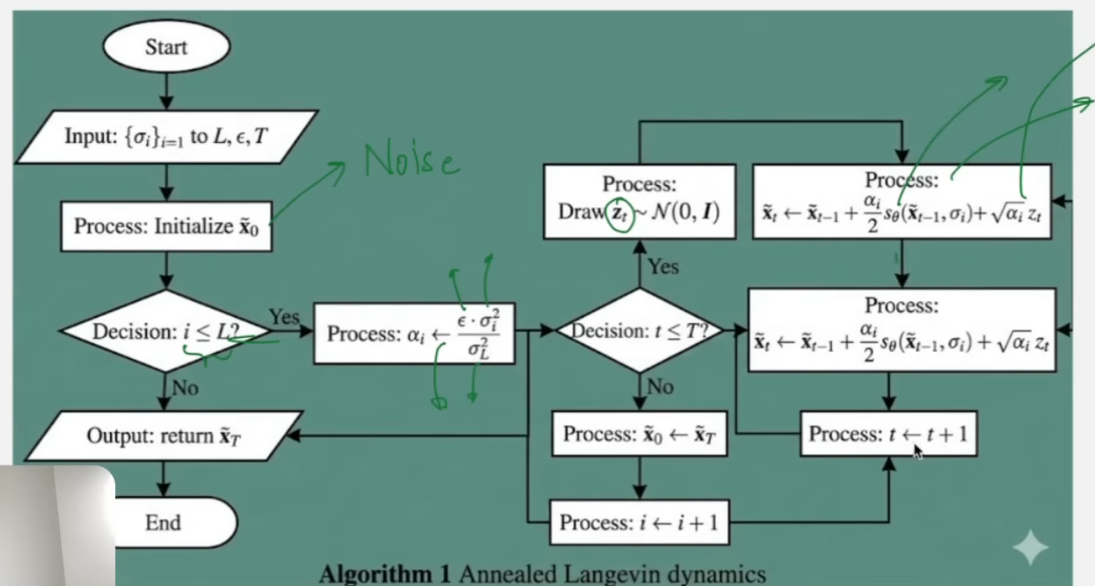

In [ ]:
def annealed_langevin_dynamics(model, sigmas, n_samples=16, step_lr=0.00002, T=100):
    """
    Generation process as per Song & Ermon (2019).
    """
    model.eval()

    # 1. Initialize with random noise
    x = torch.rand(n_samples, 3, 32, 32).to(DEVICE)

    # 2. Annealing Loop (Loop over noise levels)
    with torch.no_grad():
        for i, sigma in enumerate(tqdm(sigmas)):    #### 10 sigmas are there
            sigma_val = sigma.item()
            labels = torch.ones(n_samples, device=DEVICE).long() * i

            # Step size calculation (alpha_i from paper)
            # alpha_i = epsilon * sigma_i^2 / sigma_L^2
            alpha = step_lr * (sigma_val / sigmas[-1].item()) ** 2

            # 3. Langevin Dynamics Loop (Refinement steps at this noise level)
            for t in range(T):
                z = torch.randn_like(x)

                # Get Score
                score = model(x, labels, sigma.repeat(n_samples))

                # Langevin Update Rule:
                # x_{t+1} = x_t + (alpha/2) * score + sqrt(alpha) * z
                x = x + (alpha / 2) * score + np.sqrt(alpha) * z


    return x


In [ ]:
# Sampling Hyperparameters
# Note: These need careful tuning. If images look like TV static, reduce Step LR.
STEP_LR = 0.00001
STEPS_PER_SIGMA = 100

print("Generating Samples...")
generated_images = annealed_langevin_dynamics(
    model,
    sigmas,
    n_samples=16,
    step_lr=STEP_LR,
    T=STEPS_PER_SIGMA
)

show_images(generated_images, "Generated Samples (Annealed Langevin)")